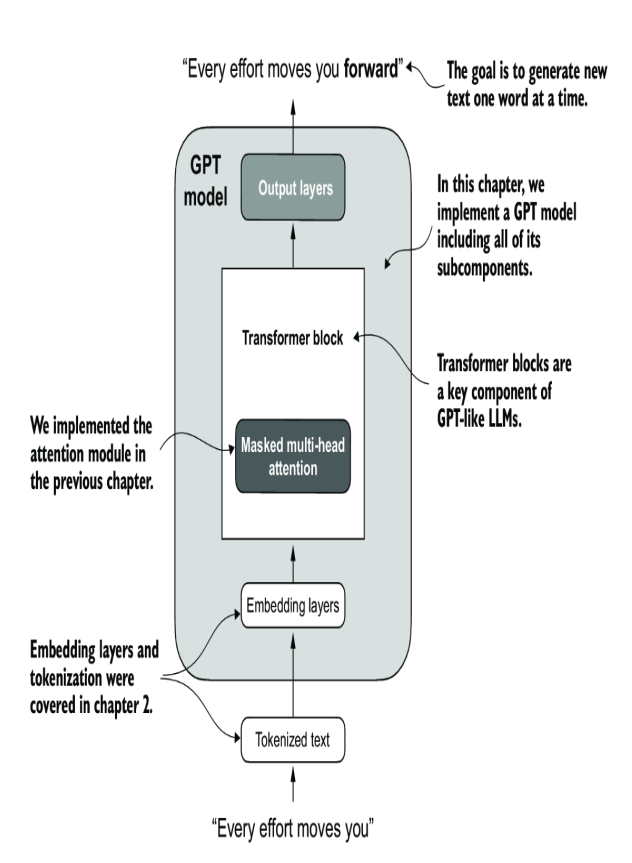
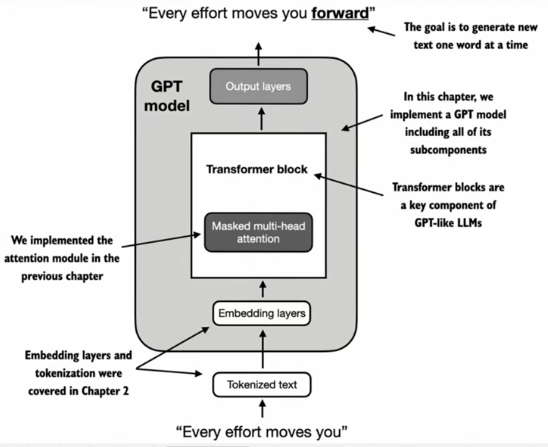

Transformer Block is the most important part of any LLM like GPT

Let's deep dive into this block

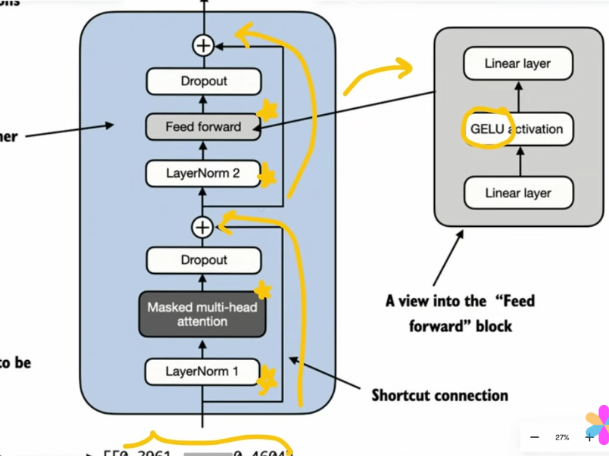

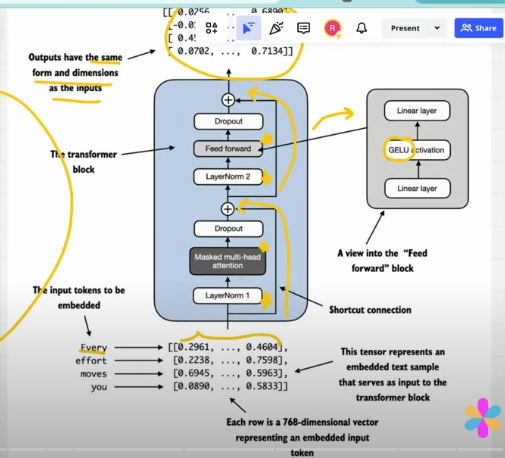

What we have learnt so far: 

1. Input Tokenization 
2. Embedding (Token + Positional)
3. Masked Mutlihead Attention 

What we are yet to learn 

1. Transformer Block 

We will scale upto the size of a small GPT-2 model 

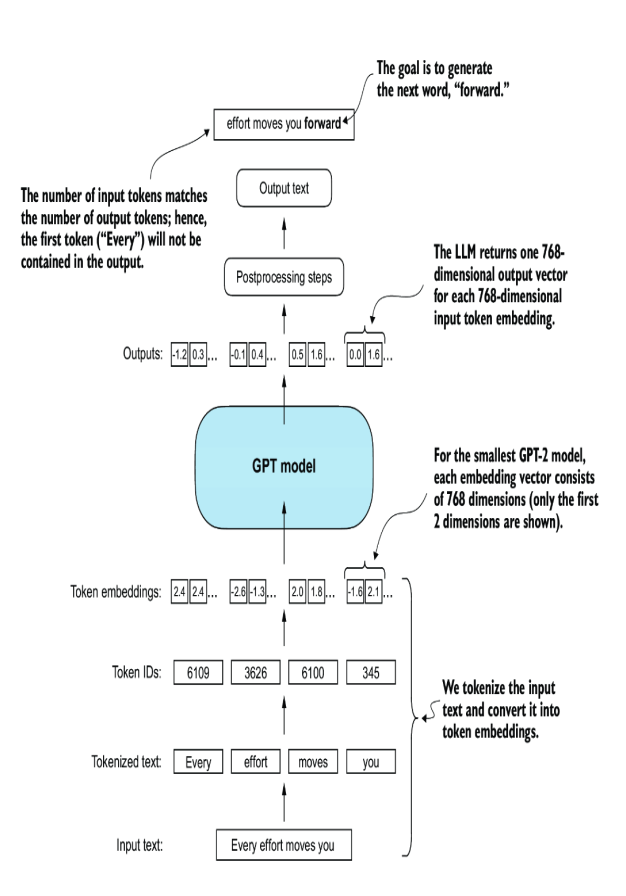

Open AI has made GPT-2 weights public. GPT-3,4 are private

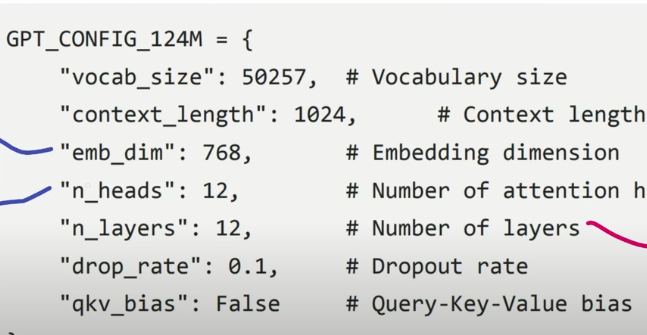

n_layers = 12, means there will be 12 transformer blocks. 

Using this configuration, we will build a GPT placeholder architecture. 

This will give us a birds eye view of how everything fits toghether.

### Implementing a GPT model from scratch to generate text

In [1]:
GPT_CONFIG_124M = {
    "vocab_size": 50257,    # Vocabulary size
    "context_length": 1024, # Context length
    "emb_dim": 768,         # Embedding dimension
    "n_heads": 12,          # Number of attention heads
    "n_layers": 12,         # Number of layers
    "drop_rate": 0.1,       # Dropout rate
    "qkv_bias": False       # Query-Key-Value bias
}

### GPT ARCHITECTURE PART 1: DUMMY GPT MODEL CLASS

Step 1: Use a placeholder for TransformerBlock

Step 2: Use a placeholder for LayerNorm

In [ ]:
import torch
import torch.nn as nn


class DummyGPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])  #thus is the weight matrix of the token embedding (look up table)
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"]) #this is the positional mebedding look up table 
        self.drop_emb = nn.Dropout(cfg["drop_rate"]) #will be discussed later
        
        # Use a placeholder for TransformerBlock
        self.trf_blocks = nn.Sequential(
            *[DummyTransformerBlock(cfg) for _ in range(cfg["n_layers"])]) #the transformer block dummy
        
        # Use a placeholder for LayerNorm
        self.final_norm = DummyLayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(
            cfg["emb_dim"], cfg["vocab_size"], bias=False
        ) #layer norm dummy, a neural network layer 

    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape #input tensors
        tok_embeds = self.tok_emb(in_idx) #pulling the embedding tensors for all token ids 
        pos_embeds = self.pos_emb(torch.arange(seq_len, device=in_idx.device)) #pulling the positional embedding for all the placeholders 
        x = tok_embeds + pos_embeds #summing both to get the input embeddings
        x = self.drop_emb(x) #discussed later
        x = self.trf_blocks(x) #transformer block
        x = self.final_norm(x)  # 4x768 dimension/ taking the values thorugh the layer normalization 
        logits = self.out_head(x) # 4x768 multiply with 768x50257 
        #these logits are the most important for each of the token we will have the probabilites of all the words in the vocabulary, the one with the largest probabilty will be returned and decoded 
        return logits


class DummyTransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        # A simple placeholder

    def forward(self, x):
        # This block does nothing and just returns its input.
        return x


class DummyLayerNorm(nn.Module):
    def __init__(self, normalized_shape, eps=1e-5):
        super().__init__()
        # The parameters here are just to mimic the LayerNorm interface.

    def forward(self, x):
        # This layer does nothing and just returns its input.
        return x

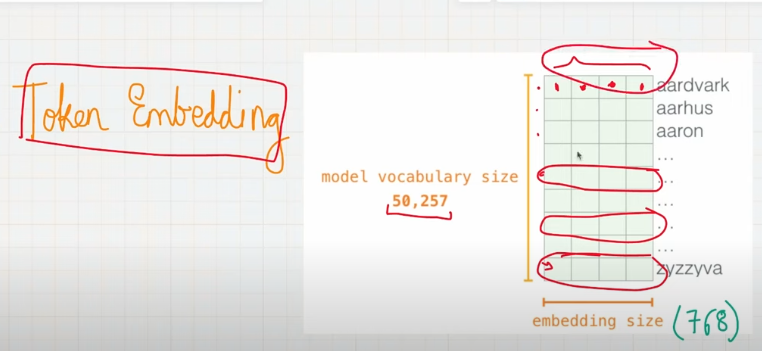

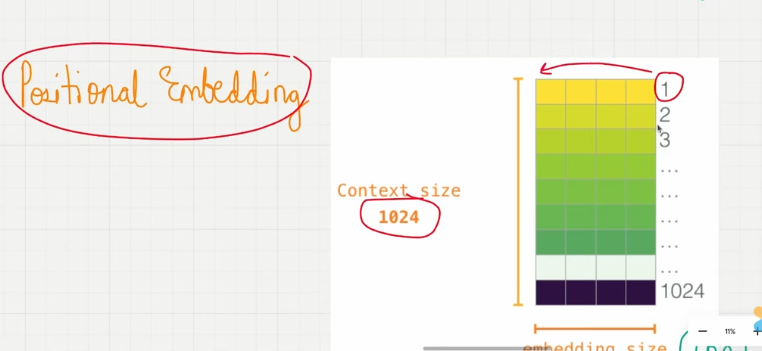

The DummyGPTModel class in this code defines a simplified version of a GPT-like model using PyTorch's neural network module (nn.Module).

The model architecture in the DummyGPTModel class consists of token and positional embeddings, dropout, a series of transformer blocks (DummyTransformerBlock), a final layer normalization (DummyLayerNorm), and a linear output layer (out_head).

The configuration is passed in via a Python dictionary, for instance, the GPT_CONFIG_124M dictionary we created earlier.

The forward method describes the data flow through the model: it computes token and positional embeddings for the input indices, applies dropout, processes the data through the transformer blocks, applies normalization, and finally produces logits with the linear output layer.

The code above is already functional, as we will see later in this section after we prepare the input data.

However, for now, note in the code above that we have used placeholders (DummyLayerNorm and DummyTransformerBlock) for the transformer block and layer normalization, which we will develop in later sections

Next, we will prepare the input data and initialize a new GPT model to illustrate its usage.

In [5]:
import tiktoken
tokenizer = tiktoken.get_encoding("gpt2")
batch = []
txt1 = "Every effort moves you"
txt2 = "Every day holds a"
batch.append(torch.tensor(tokenizer.encode(txt1)))
batch.append(torch.tensor(tokenizer.encode(txt2)))
batch = torch.stack(batch, dim=0)
print(batch)

tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])


In [6]:
torch.manual_seed(123)
model = DummyGPTModel(GPT_CONFIG_124M)
logits = model(batch)
print("Output shape:", logits.shape)
print()
print("-"*100)
print()
print(logits)

Output shape: torch.Size([2, 4, 50257])

----------------------------------------------------------------------------------------------------

tensor([[[-0.9289,  0.2748, -0.7557,  ..., -1.6070,  0.2702, -0.5888],
         [-0.4476,  0.1726,  0.5354,  ..., -0.3932,  1.5285,  0.8557],
         [ 0.5680,  1.6053, -0.2155,  ...,  1.1624,  0.1380,  0.7425],
         [ 0.0448,  2.4787, -0.8843,  ...,  1.3219, -0.0864, -0.5856]],

        [[-1.5474, -0.0542, -1.0571,  ..., -1.8061, -0.4494, -0.6747],
         [-0.8422,  0.8243, -0.1098,  ..., -0.1434,  0.2079,  1.2046],
         [ 0.1355,  1.1858, -0.1453,  ...,  0.0869, -0.1590,  0.1552],
         [ 0.1666, -0.8138,  0.2307,  ...,  2.5035, -0.3055, -0.3083]]],
       grad_fn=<UnsafeViewBackward0>)


The output tensor has two rows corresponding to the two text samples. Each text sample consists of 4 tokens; each token is a 50,257-dimensional vector, which matches the size of the tokenizer's vocabulary.

The embedding has 50,257 dimensions because each of these dimensions refers to a unique token in the vocabulary. At the end of this chapter, when we implement the postprocessing code, we will convert these 50,257-dimensional vectors back into token IDs, which we can then decode into words.